# Import Libraries & Load the Data

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Notes(EDA)\dataset\dataset.csv")

In [5]:
df.head(5)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JTMEB3FV6N,Monroe,Key West,FL,33040,2022,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42,0,NaN,198968248,POINT (-81.80023 24.5545),NaN,12087972100
1,1G1RD6E45D,Clark,Laughlin,NV,89029,2013,CHEVROLET,VOLT,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,0,NaN,5204412,POINT (-114.57245 35.16815),NaN,32003005702
2,JN1AZ0CP8B,Yakima,Yakima,WA,98901,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73,0,15.0,218972519,POINT (-120.50721 46.60448),PACIFICORP,53077001602
3,1G1FW6S08H,Skagit,Concrete,WA,98237,2017,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238,0,39.0,186750406,POINT (-121.7515 48.53892),PUGET SOUND ENERGY INC,53057951101
4,3FA6P0SU1K,Snohomish,Everett,WA,98201,2019,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,0,38.0,2006714,POINT (-122.20596 47.97659),PUGET SOUND ENERGY INC,53061041500


# Inspection of Data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112634 entries, 0 to 112633
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         112634 non-null  object 
 1   County                                             112634 non-null  object 
 2   City                                               112634 non-null  object 
 3   State                                              112634 non-null  object 
 4   Postal Code                                        112634 non-null  int64  
 5   Model Year                                         112634 non-null  int64  
 6   Make                                               112634 non-null  object 
 7   Model                                              112614 non-null  object 
 8   Electric Vehicle Type                              112634 non-null  object

In [7]:
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,112634.000000,112634.000000,112634.000000,112634.000000,112348.000000,1.126340e+05,1.126340e+05
mean,98156.226850,2019.003365,87.812987,1793.439681,29.805604,1.994567e+08,5.296650e+10
std,2648.733064,2.892364,102.334216,10783.753486,14.700545,9.398427e+07,1.699104e+09
min,1730.000000,1997.000000,0.000000,0.000000,1.000000,4.777000e+03,1.101001e+09
25%,98052.000000,2017.000000,0.000000,0.000000,18.000000,1.484142e+08,5.303301e+10
50%,98119.000000,2020.000000,32.000000,0.000000,34.000000,1.923896e+08,5.303303e+10
75%,98370.000000,2022.000000,208.000000,0.000000,43.000000,2.191899e+08,5.305307e+10
max,99701.000000,2023.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.603300e+10


In [8]:
df.columns=df.columns.str.lower()

In [9]:
df.columns=df.columns.str.replace(" ","_")

In [10]:
df = df.rename(columns={"make": "brand"})

In [11]:
df = df.rename(columns={"model": "model_name"})

In [12]:
df.columns

Index(['vin_(1-10)', 'county', 'city', 'state', 'postal_code', 'model_year',
       'brand', 'model_name', 'electric_vehicle_type',
       'clean_alternative_fuel_vehicle_(cafv)_eligibility', 'electric_range',
       'base_msrp', 'legislative_district', 'dol_vehicle_id',
       'vehicle_location', 'electric_utility', '2020_census_tract'],
      dtype='object')

In [13]:
df.shape

(112634, 17)

In [14]:
df.isnull().sum()

vin_(1-10)                                             0
county                                                 0
city                                                   0
state                                                  0
postal_code                                            0
model_year                                             0
brand                                                  0
model_name                                            20
electric_vehicle_type                                  0
clean_alternative_fuel_vehicle_(cafv)_eligibility      0
electric_range                                         0
base_msrp                                              0
legislative_district                                 286
dol_vehicle_id                                         0
vehicle_location                                      24
electric_utility                                     443
2020_census_tract                                      0
dtype: int64

In [15]:
df["model_name"].value_counts()

model_name
MODEL 3        23135
MODEL Y        17142
LEAF           12880
MODEL S         7377
BOLT EV         4910
               ...  
745LE              2
S-10 PICKUP        1
SOLTERRA           1
918                1
FLYING SPUR        1
Name: count, Length: 114, dtype: int64

In [16]:
df["model_name"].nunique()

114

In [17]:
df["legislative_district"].value_counts()

legislative_district
41.0    7605
45.0    7112
48.0    6462
36.0    5251
46.0    4723
1.0     4715
5.0     4694
43.0    4621
37.0    3556
34.0    3478
18.0    3024
22.0    2782
32.0    2709
11.0    2707
44.0    2670
40.0    2633
23.0    2626
21.0    2617
26.0    2267
33.0    2112
10.0    2061
31.0    1912
17.0    1907
47.0    1876
24.0    1664
27.0    1654
42.0    1626
35.0    1620
39.0    1574
49.0    1573
28.0    1448
30.0    1268
2.0     1226
8.0     1157
38.0    1079
25.0    1049
6.0     1041
12.0    1004
20.0     973
4.0      845
13.0     748
14.0     720
29.0     692
19.0     672
16.0     611
9.0      606
3.0      557
7.0      544
15.0     277
Name: count, dtype: int64

In [18]:
df["electric_utility"].value_counts()

electric_utility
PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)                                               40247
PUGET SOUND ENERGY INC                                                                      22172
CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)                                                21447
BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF CLARK COUNTY - (WA)                             6522
BONNEVILLE POWER ADMINISTRATION||CITY OF TACOMA - (WA)||PENINSULA LIGHT COMPANY              5053
                                                                                            ...  
BONNEVILLE POWER ADMINISTRATION||PENINSULA LIGHT COMPANY                                        1
BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF ASOTIN COUNTY                                      1
CITY OF SEATTLE - (WA)                                                                          1
BONNEVILLE POWER ADMINISTRATION||NESPELEM VALLEY ELEC COOP, INC                                 1
BON

In [19]:
df["vehicle_location"].value_counts()

vehicle_location
POINT (-122.13158 47.67858)    2916
POINT (-122.2066 47.67887)     2059
POINT (-122.1872 47.61001)     2001
POINT (-122.31765 47.70013)    1880
POINT (-122.12096 47.55584)    1852
                               ... 
POINT (-124.33152 48.05431)       1
POINT (-77.41203 39.41574)        1
POINT (-123.61022 46.35588)       1
POINT (-112.04165 40.68741)       1
POINT (-116.91895 47.40077)       1
Name: count, Length: 758, dtype: int64

# Handling Missing Values

In [20]:
df["vehicle_location"] = df["vehicle_location"].fillna(df["vehicle_location"].mode()[0])

In [21]:
df["electric_utility"] = df["electric_utility"].fillna(df["electric_utility"].mode()[0])

In [22]:
df["legislative_district"]=df["legislative_district"].fillna(df["legislative_district"].mean())

In [23]:
df["model_name"]=df["model_name"].fillna(df["model_name"].mode()[0])

In [24]:
df.isnull().sum()

vin_(1-10)                                           0
county                                               0
city                                                 0
state                                                0
postal_code                                          0
model_year                                           0
brand                                                0
model_name                                           0
electric_vehicle_type                                0
clean_alternative_fuel_vehicle_(cafv)_eligibility    0
electric_range                                       0
base_msrp                                            0
legislative_district                                 0
dol_vehicle_id                                       0
vehicle_location                                     0
electric_utility                                     0
2020_census_tract                                    0
dtype: int64

In [25]:
df.duplicated().sum()

0

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112634 entries, 0 to 112633
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   vin_(1-10)                                         112634 non-null  object 
 1   county                                             112634 non-null  object 
 2   city                                               112634 non-null  object 
 3   state                                              112634 non-null  object 
 4   postal_code                                        112634 non-null  int64  
 5   model_year                                         112634 non-null  int64  
 6   brand                                              112634 non-null  object 
 7   model_name                                         112634 non-null  object 
 8   electric_vehicle_type                              112634 non-null  object

In [27]:
pd.crosstab(df.state, df.electric_vehicle_type, normalize='index')

electric_vehicle_type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
state,,
AK,0.000000,1.000000
AL,0.000000,1.000000
AR,0.750000,0.250000
AZ,0.666667,0.333333
CA,0.657895,0.342105
CO,0.777778,0.222222
CT,0.166667,0.833333
DC,0.666667,0.333333
DE,1.000000,0.000000


# Feature Engineering

In [28]:
import datetime
current_year = datetime.datetime.now().year
df["EV_Age"]=current_year-df["model_year"]

In [29]:
df = df.drop(columns=["vin_(1-10)"])

In [30]:
df["estimated_price"] = df["base_msrp"] * 1.08  

In [31]:
df["price_range"] = pd.cut(
    df["base_msrp"],
    bins=[0, 30000, 60000, 100000, 200000],
    labels=["Low", "Mid", "High", "Premium"]
)

In [32]:
df['EV_Type'] = df['electric_vehicle_type'].apply(lambda x:'BEV' if 'Battery' in x else 'PHEV')


In [33]:
import re

df['latitude'] = df['vehicle_location'].str.extract(r'\(([-\d\.]+)')
df['longitude'] = df['vehicle_location'].str.extract(r' ([\-\d\.]+)\)')
df[['latitude', 'longitude']] = df[['latitude', 'longitude']].astype(float)


In [34]:
df[['latitude', 'longitude']]

,latitude,longitude
0,-81.80023,24.55450
1,-114.57245,35.16815
2,-120.50721,46.60448
3,-121.75150,48.53892
4,-122.20596,47.97659
...,...,...
112629,-121.98609,47.74068
112630,-123.01648,48.53448
112631,-122.45730,47.44929
112632,-122.09124,47.33778


In [35]:
df["model_year"]

0         2022
1         2013
2         2011
3         2017
4         2019
          ... 
112629    2022
112630    2019
112631    2022
112632    2018
112633    2022
Name: model_year, Length: 112634, dtype: int64

In [36]:
df["brand"].value_counts()

brand
TESLA             52078
NISSAN            12880
CHEVROLET         10182
FORD               5819
BMW                4680
KIA                4483
TOYOTA             4405
VOLKSWAGEN         2514
AUDI               2332
VOLVO              2288
CHRYSLER           1794
HYUNDAI            1412
JEEP               1152
RIVIAN              885
FIAT                822
PORSCHE             818
HONDA               792
MINI                632
MITSUBISHI          588
POLESTAR            558
MERCEDES-BENZ       506
SMART               273
JAGUAR              219
LINCOLN             168
CADILLAC            108
LUCID MOTORS         65
SUBARU               59
LAND ROVER           38
LEXUS                33
FISKER               20
GENESIS              18
AZURE DYNAMICS        7
TH!NK                 3
BENTLEY               3
Name: count, dtype: int64

In [37]:
make_year_sales = df.groupby(["brand", "model_year"]).size().reset_index(name="Total_Sales")

In [38]:
pivot_table = df.pivot_table(index="brand",columns="model_year",aggfunc="size",fill_value=0)
pivot_table

model_year,1997,1998,1999,2000,2002,2008,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
brand,,,,,,,,,,,,,,,,,,,,
AUDI,0,0,0,0,0,0,0,0,0,0,0,0,214,187,174,392,224,544,585,12
AZURE DYNAMICS,0,0,0,0,0,0,0,4,3,0,0,0,0,0,0,0,0,0,0,0
BENTLEY,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0
BMW,0,0,0,0,0,0,0,0,0,0,457,403,383,692,710,279,143,635,905,73
CADILLAC,0,0,0,0,0,0,0,0,0,0,58,0,18,15,17,0,0,0,0,0
CHEVROLET,1,0,0,0,0,0,0,71,496,818,724,467,309,2744,1126,966,1014,377,892,177
CHRYSLER,0,0,0,0,0,0,0,0,0,0,0,0,0,94,554,119,286,504,237,0
FIAT,0,0,0,0,0,0,0,0,0,106,97,242,148,167,53,9,0,0,0,0
FISKER,0,0,0,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0


In [ ]:

year_trend = df.groupby("model_year").size().reset_index(name="count")
print(year_trend)

In [107]:
market_share = df["brand"].value_counts().reset_index()
market_share.columns = ["brand", "count"]

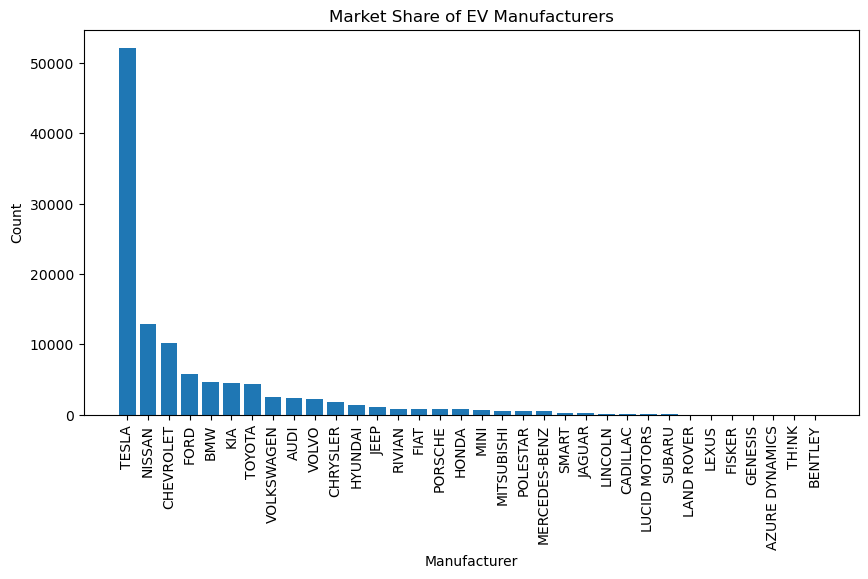

In [43]:
plt.figure(figsize=(10,5))
plt.bar(market_share["brand"], market_share["count"])
plt.title("Market Share of EV Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()


In [85]:
#Outlier Detection

if 'electric_range' in df.columns:
    Q1 = df['electric_range'].quantile(0.25)
    Q3 = df['electric_range'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df['electric_range'] < lower) | (df['electric_range'] > upper)]
    print('electric_range outliers count:', len(outliers))
    display(outliers[['brand','model_','model_year','electric_range']].head(10))
    # Option to remove outliers
    df_no_out = df[~((df['electric_range'] < lower) | (df['electric_range'] > upper))].copy()
    print('Shape without outliers:', df_no_out.shape)
else:
    print('electric_range not in columns.')

electric_range outliers count: 22


,brand,model_name,model_year,electric_range
47,TESLA,MODEL 3,2018,215
55,TESLA,MODEL Y,2020,291
6380,TESLA,MODEL 3,2020,322
6524,TESLA,MODEL 3,2020,308
7141,TESLA,MODEL 3,2019,220
13671,TESLA,MODEL 3,2018,215
17568,TESLA,MODEL 3,2019,220
24718,TESLA,MODEL 3,2019,220
58147,TESLA,MODEL 3,2019,220
60628,TESLA,MODEL 3,2019,220


Shape without outliers: (111, 22)


# Univariate Analysis

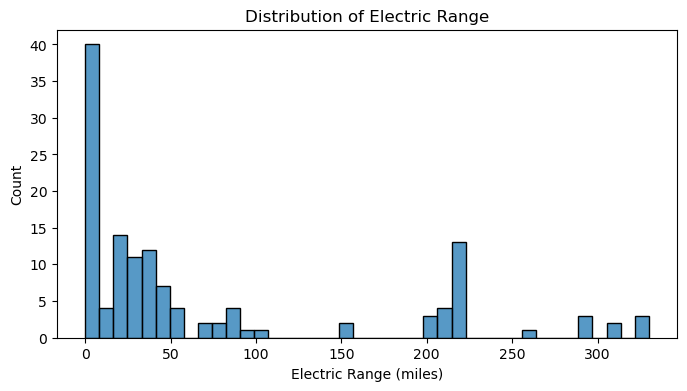

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df["electric_range"], bins=40)
plt.title("Distribution of Electric Range")
plt.xlabel("Electric Range (miles)")
plt.show()


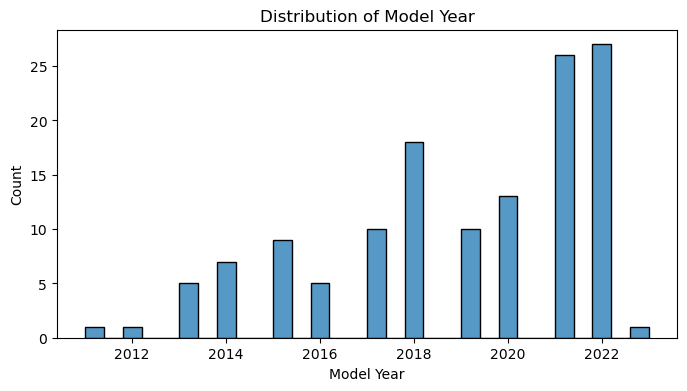

In [87]:
plt.figure(figsize=(8,4))
sns.histplot(df["model_year"], bins=30)
plt.title("Distribution of Model Year")
plt.xlabel("Model Year")
plt.show()


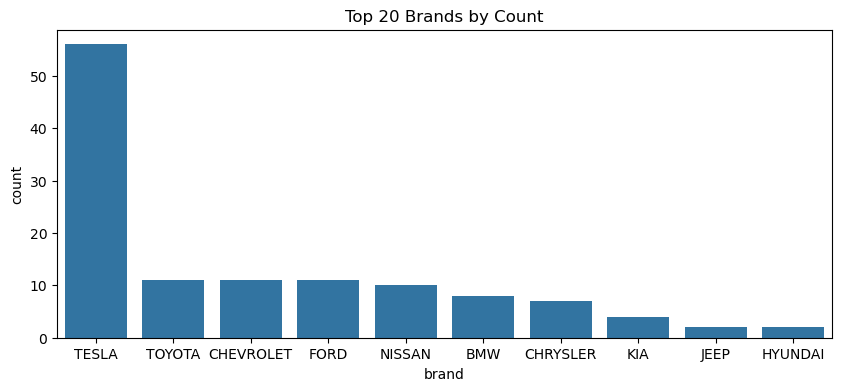

In [ ]:
plt.figure(figsize=(10,4))
sns.countplot(x=df["brand"], order=df["brand"].value_counts().head(10).index)
plt.title("Top 10 Brands by Count")
plt.show()


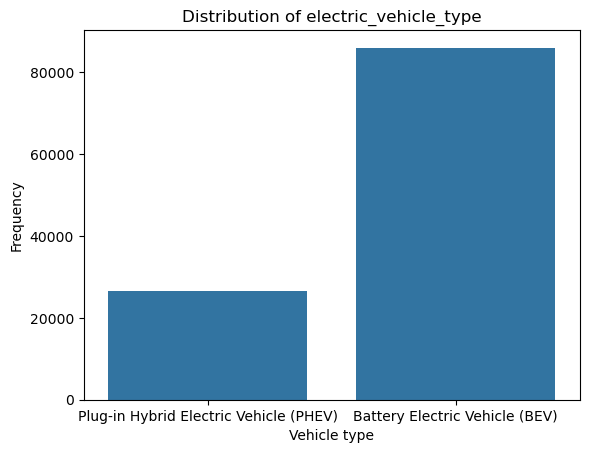

In [46]:
sns.countplot(df,x="electric_vehicle_type")

plt.title("Distribution of electric_vehicle_type")
plt.xlabel("Vehicle type")
plt.ylabel("Frequency")
plt.show()

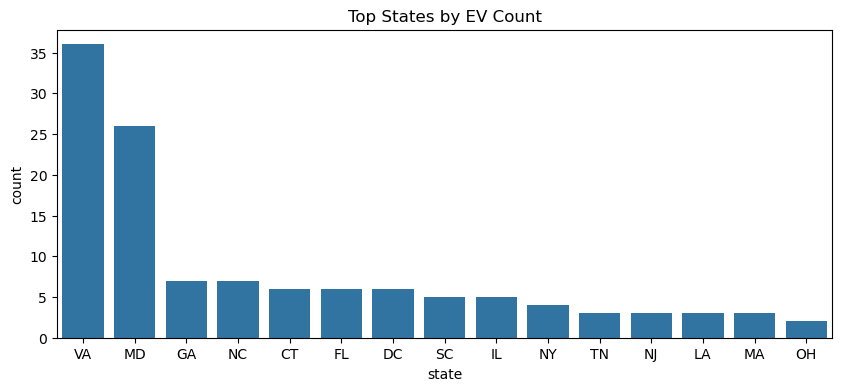

In [96]:
plt.figure(figsize=(10,4))
sns.countplot(x=df["state"], order=df["state"].value_counts().head(15).index)
plt.title("Top States by EV Count")
plt.show()


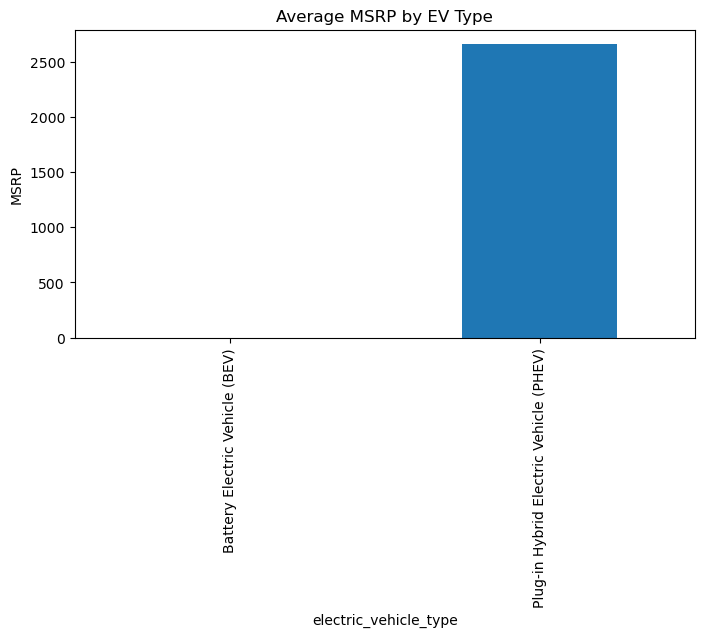

In [ ]:
evtype_price = df.groupby("electric_vehicle_type")["base_msrp"].mean()

plt.figure(figsize=(8,4))
evtype_price.plot(kind='bar')
plt.title("Average MSRP by EV Type")
plt.ylabel("MSRP")
plt.show()

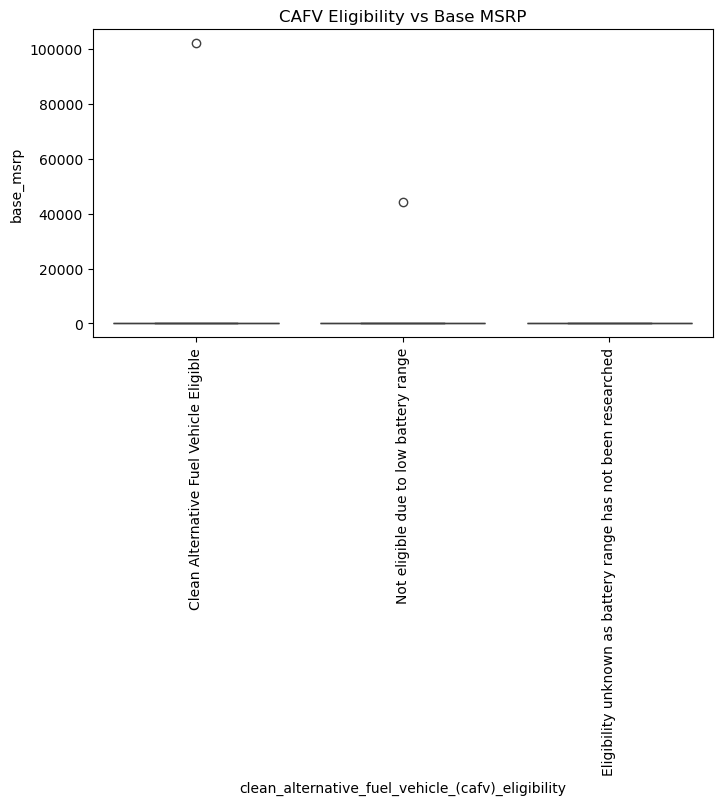

In [105]:
plt.figure(figsize=(8,4))
sns.boxplot(x="clean_alternative_fuel_vehicle_(cafv)_eligibility", y="base_msrp", data=df)
plt.title("CAFV Eligibility vs Base MSRP")
plt.xticks(rotation=90)
plt.show()

# Bivariate Analysis

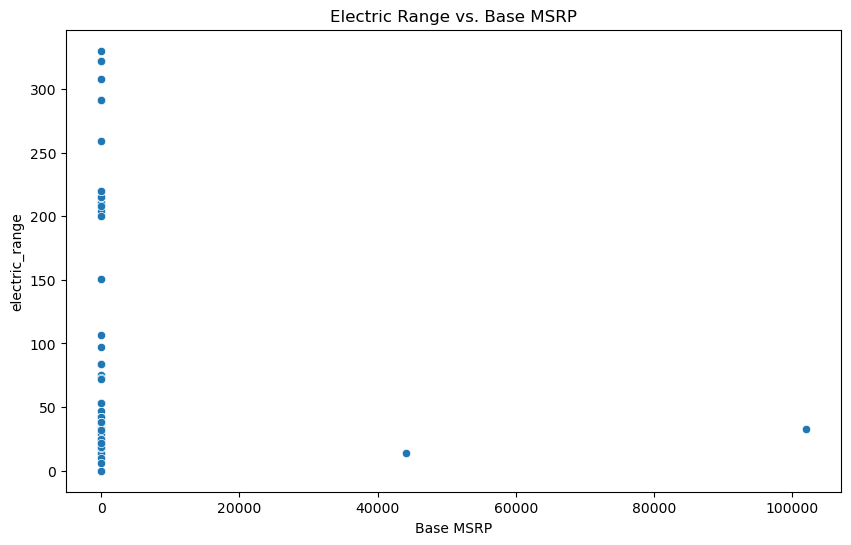

In [76]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="base_msrp", y="electric_range", data=df)
plt.title('Electric Range vs. Base MSRP')
plt.xlabel('Base MSRP')
plt.show()

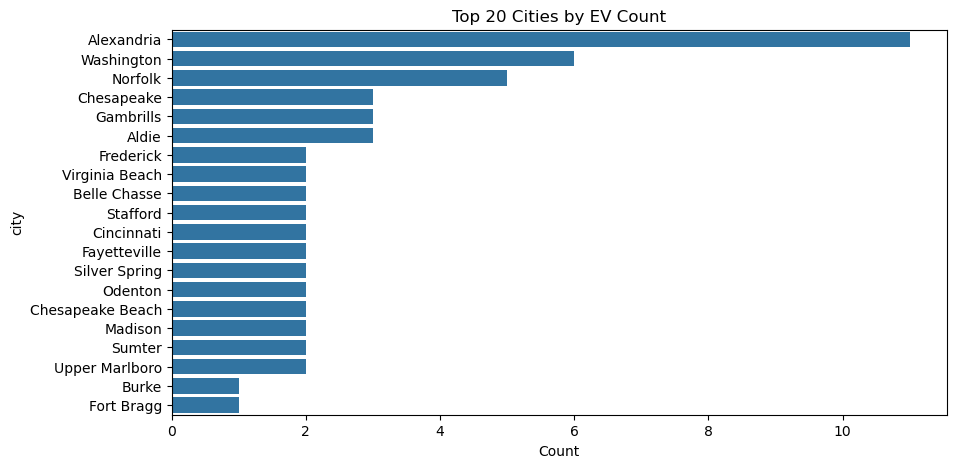

In [100]:
city_count = df["city"].value_counts().head(20)

plt.figure(figsize=(10,5))
sns.barplot(x=city_count.values, y=city_count.index)
plt.title("Top 20 Cities by EV Count")
plt.xlabel("Count")
plt.show()


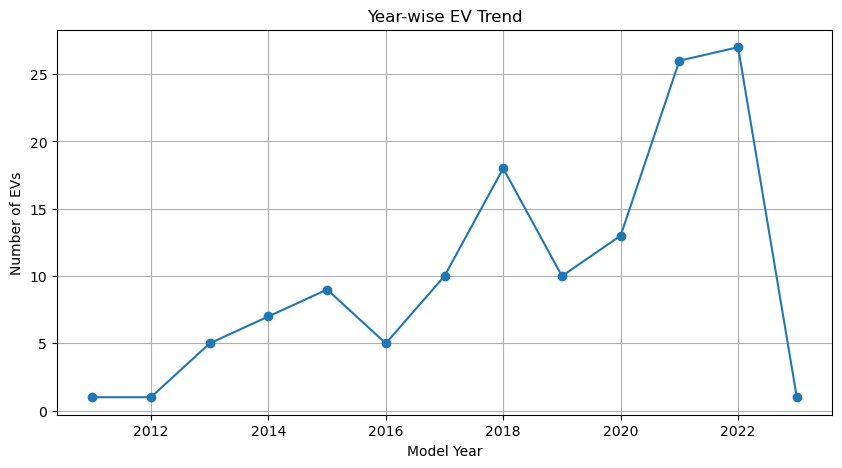

In [99]:
year_trend = df.groupby("model_year").size().reset_index(name="count")

plt.figure(figsize=(10,5))
plt.plot(year_trend["model_year"], year_trend["count"], marker='o')
plt.title("Year-wise EV Trend")
plt.xlabel("Model Year")
plt.ylabel("Number of EVs")
plt.grid(True)
plt.show()


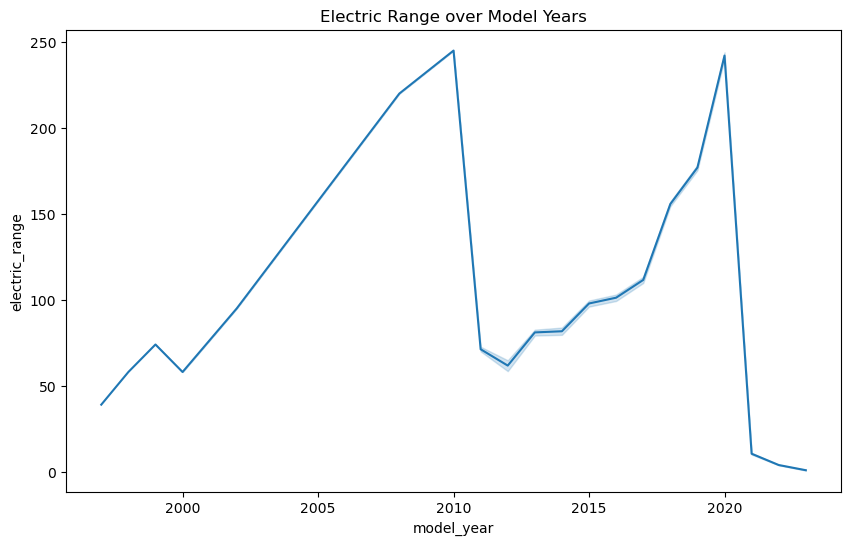

In [50]:
plt.figure(figsize=(10, 6))
sns.lineplot(x="model_year", y="electric_range", data=df)
plt.title('Electric Range over Model Years')
plt.show()

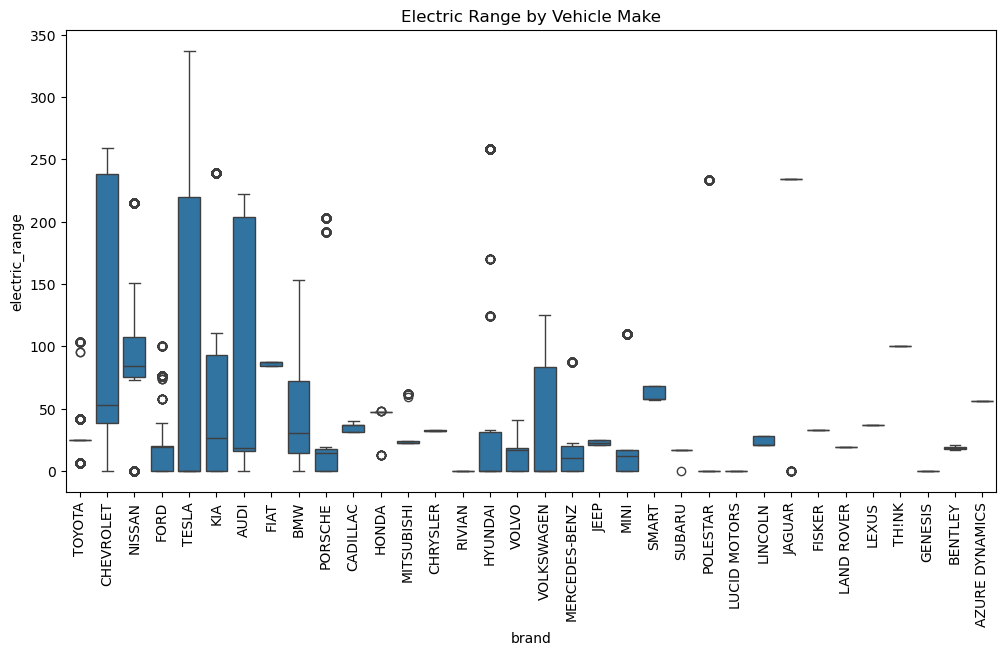

In [51]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="brand", y="electric_range", data=df)
plt.xticks(rotation=90)
plt.title('Electric Range by Vehicle Make')
plt.show()

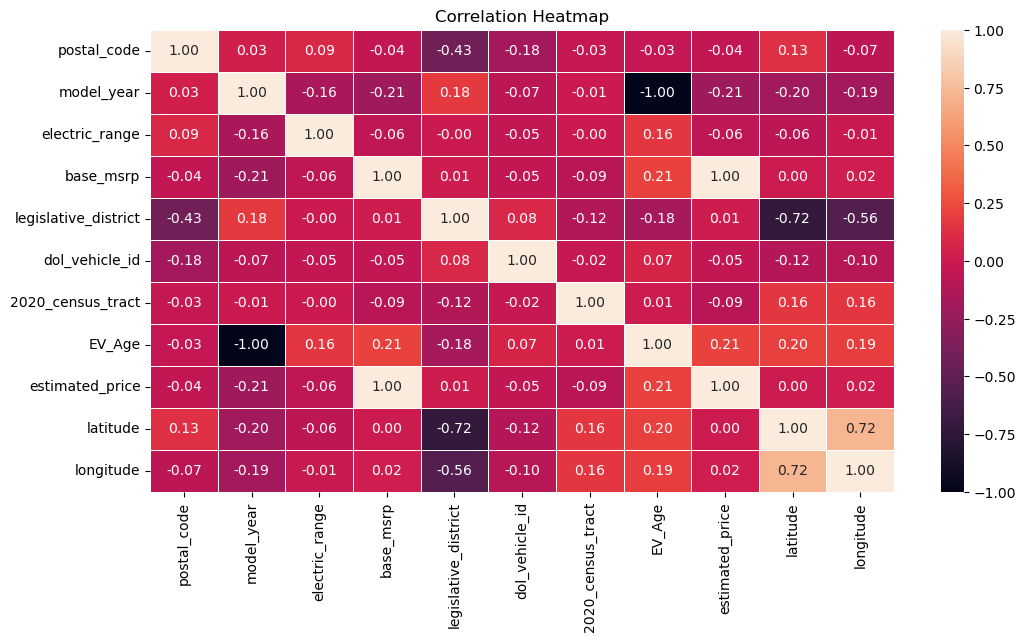

In [82]:
plt.figure(figsize=(12,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


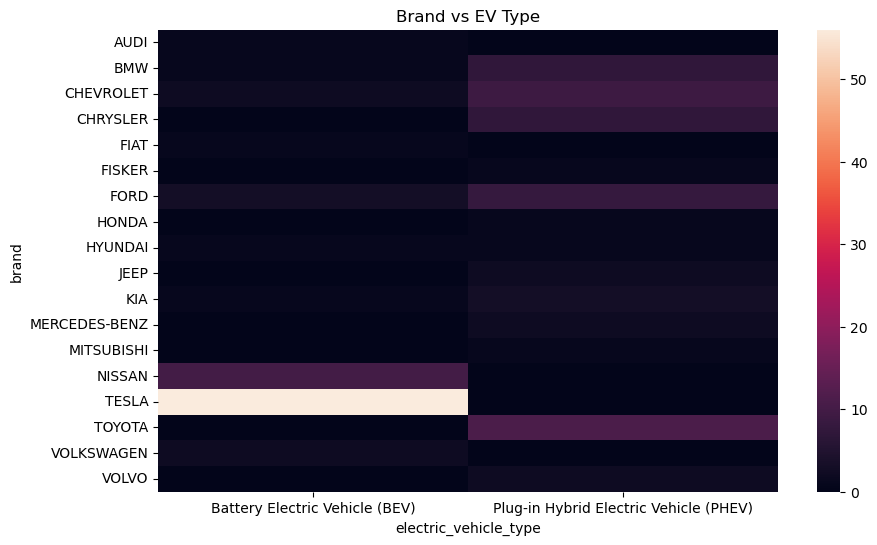

In [101]:
cross = pd.crosstab(df["brand"], df["electric_vehicle_type"])
plt.figure(figsize=(10,6))
sns.heatmap(cross, annot=False)
plt.title("Brand vs EV Type")
plt.show()

In [ ]:
import plotly.express as px


count_by_state = df.groupby("state").size().reset_index(name="count")

fig = px.choropleth(
    count_by_state,
    locations="state",
    color="count",
    locationmode="USA-states",
    scope="usa",
    labels={"count": "NO OF EV's"},  
    title="Number of EVs by State"
)

fig.update_layout(
    geo=dict(bgcolor='rgba(0,0,0,0)'),
    title_x=0.5  # Center the title
)

fig.show()

# Predict price using regression

In [123]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error

In [124]:
data = df[df['base_msrp'] > 0].copy()

In [125]:
label_cols = ['brand', 'model_name', 'state', 'electric_vehicle_type']

In [126]:
encoders = {} 
for col in label_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    encoders[col] = le  

In [127]:
X = data[['model_year', 'electric_range', 'brand', 'model_name', 'state', 'electric_vehicle_type']]
y = data['base_msrp']

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [129]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [130]:
y_pred = model.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R² Score: nan
MAE: 57900.0


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:1211: UndefinedMetricWarning:

R^2 score is not well-defined with less than two samples.



# Testing 

In [131]:
# Example new vehicle
new_vehicle = pd.DataFrame({
    'model_year': [2025],
    'electric_range': [400],
    'brand': ['RIVIAN'],
    'model_name': ['R1T'],
    'state': ['WA'],
    'electric_vehicle_type': ['battery electric vehicle (bev)']
})

In [132]:
for col in label_cols:
    # Handle unseen values gracefully
    new_vehicle[col] = new_vehicle[col].apply(lambda x: x if x in encoders[col].classes_ else encoders[col].classes_[0])
    new_vehicle[col] = encoders[col].transform(new_vehicle[col].astype(str))

In [133]:
predicted_price = model.predict(new_vehicle)
print("Predicted Vehicle Price: $", round(predicted_price[0], 2))

Predicted Vehicle Price: $ 102000.0
